In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

np.random.seed(123)
az.style.use("arviz-doc")

In [2]:
ans = pd.read_csv('../code/data/anscombe.csv')

<Axes: >

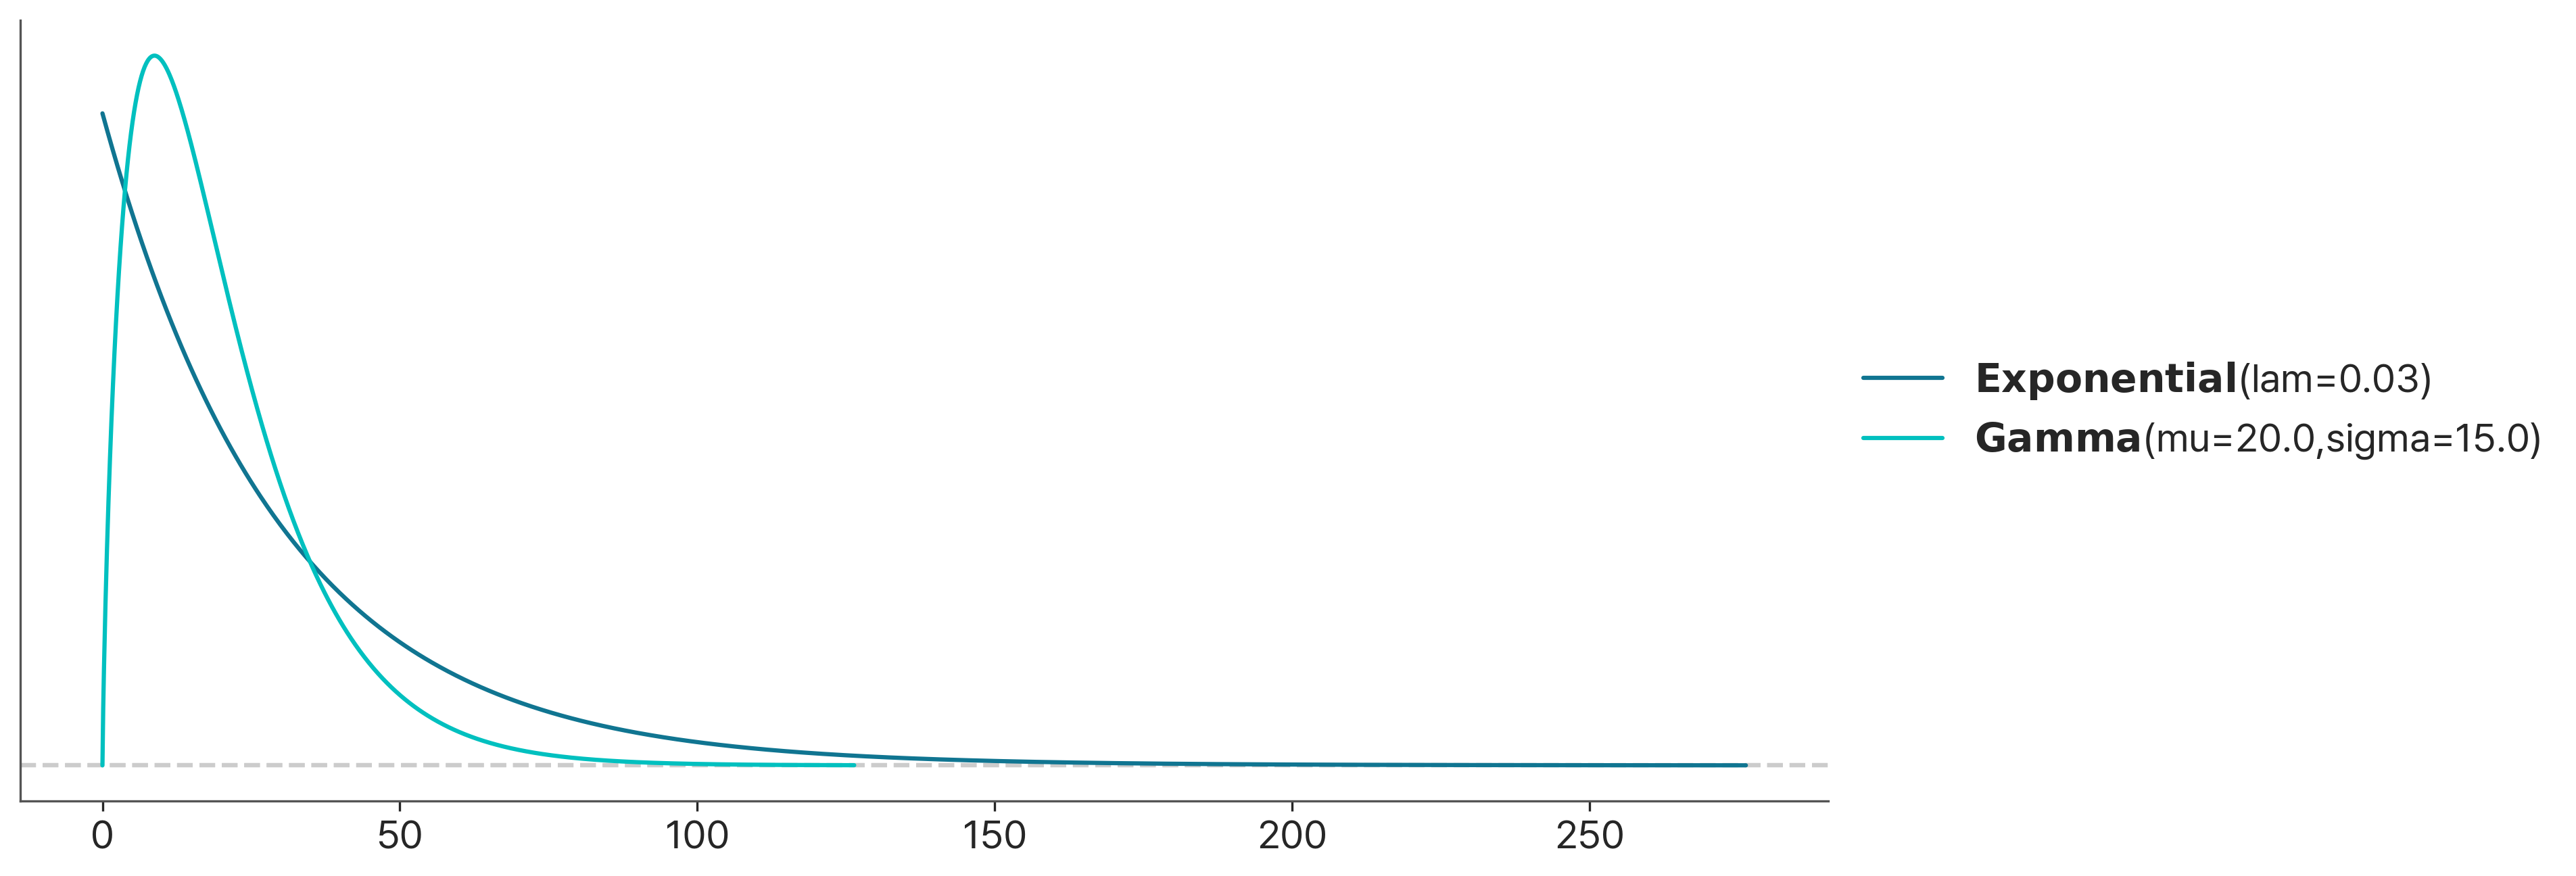

In [ ]:
pz.Exponential(1/30).plot_pdf()
pz.Gamma(mu=20, sigma=15).plot_pdf()
pz.Gamma(2, 0.1).plot_pdf();


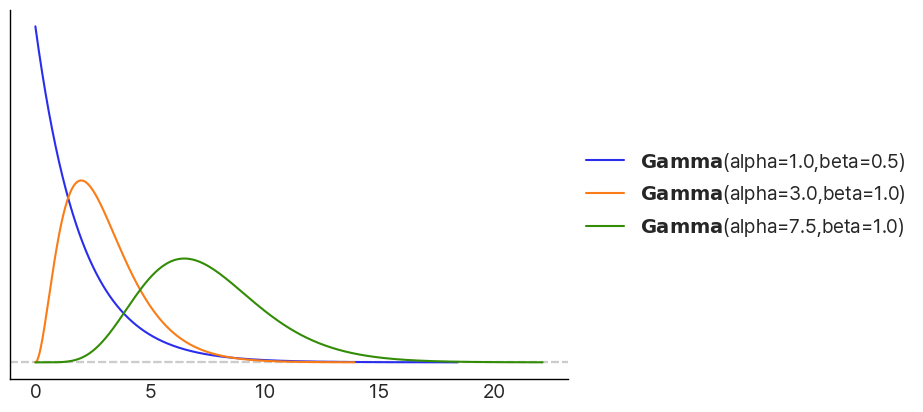

In [12]:
import arviz as az
from preliz import Gamma
az.style.use('arviz-white')
alphas = [1., 3., 7.5]
betas = [.5, 1., 1.]
for alpha, beta in zip(alphas, betas):
    Gamma(alpha, beta).plot_pdf()

<Axes: >

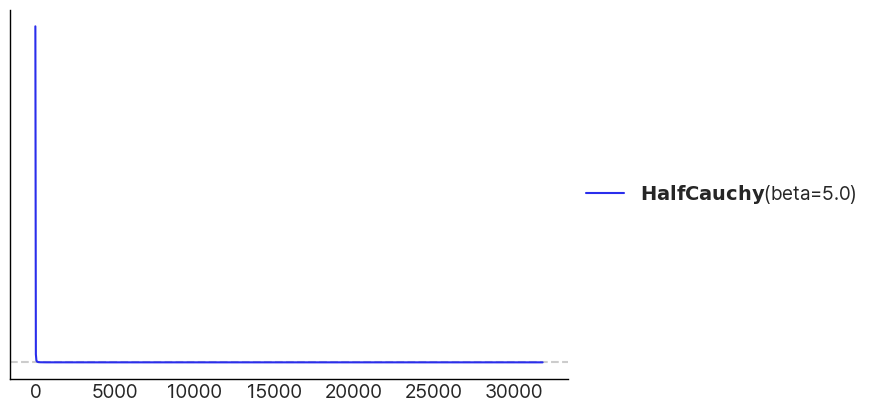

In [27]:
pz.HalfCauchy(5).plot_pdf()

In [13]:
ans

,group,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


In [15]:
x_4 = ans[ans.group== 'IV']['x'].values
x_4

array([ 8.,  8.,  8.,  8.,  8.,  8.,  8., 19.,  8.,  8.,  8.])

In [16]:
y_4 = ans[ans.group=='IV']['y'].values
y_4

array([ 6.58,  5.76,  7.71,  8.84,  8.47,  7.04,  5.25, 12.5 ,  5.56,
        7.91,  6.89])

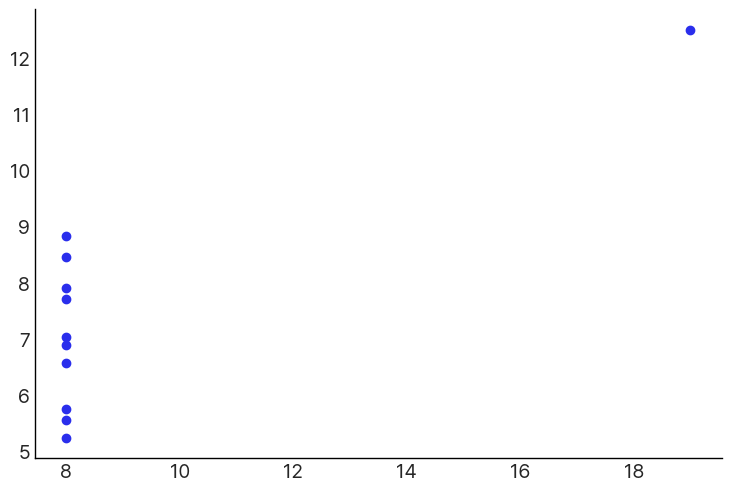

In [ ]:
plt.scatter(x_4, y_4)

In [30]:
with pm.Model() as model_t2_exp:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=1)
    sigma = pm.HalfCauchy('sigma', 5)
    nu = pm.Exponential('nu', 1/30)

    y_pred = pm.StudentT('y_pred', mu=alpha + beta * x_4, 
                         sigma=sigma, nu=nu, observed=y_4)
    
    idata_t2_exp = pm.sample_prior_predictive()
    display(idata_t2_exp)
    idata_t2_exp.extend(pm.sample())
    display(idata_t2_exp)


Sampling: [alpha, beta, nu, sigma, y_pred]


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma, nu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [38]:
with pm.Model() as model_t2_gamma:
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=1)
    sigma = pm.HalfCauchy('sigma', 5)
    nu = pm.Gamma('nu', 2, 0.1)

    y_pred = pm.StudentT('y_pred', mu=alpha + beta * x_4, 
                         sigma=sigma, nu=nu, observed=y_4)

    idata_t2_gamma = pm.sample_prior_predictive()
    idata_t2_gamma.extend(pm.sample())
    display(idata_t2_gamma)


Sampling: [alpha, beta, nu, sigma, y_pred]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma, nu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

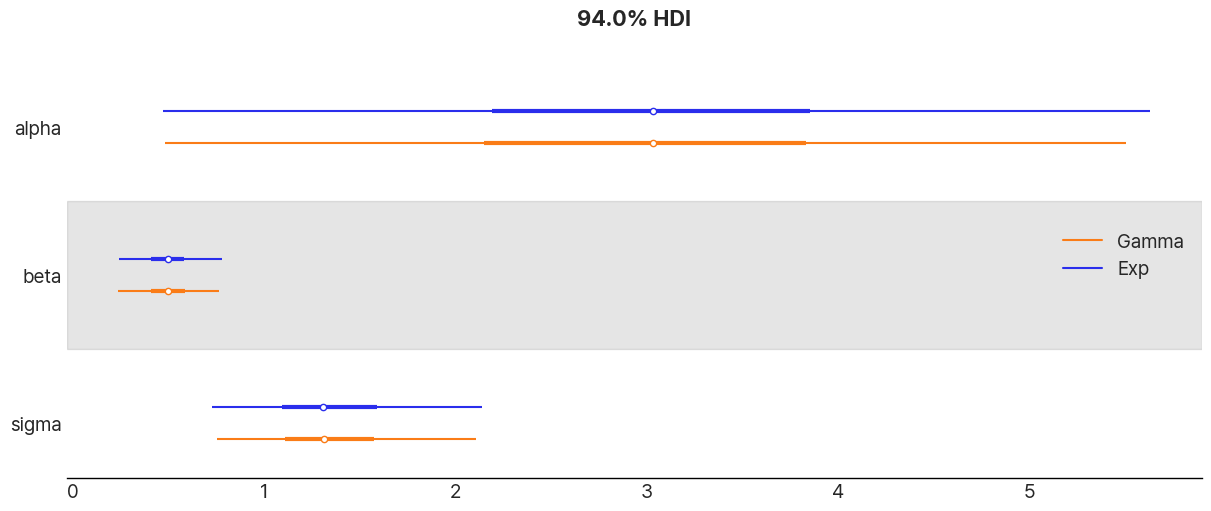

In [39]:
az.plot_forest([idata_t2_exp, idata_t2_gamma],
               model_names=['Exp', 'Gamma'],
               var_names=['~nu'], figsize=(12,5),
               combined=True)

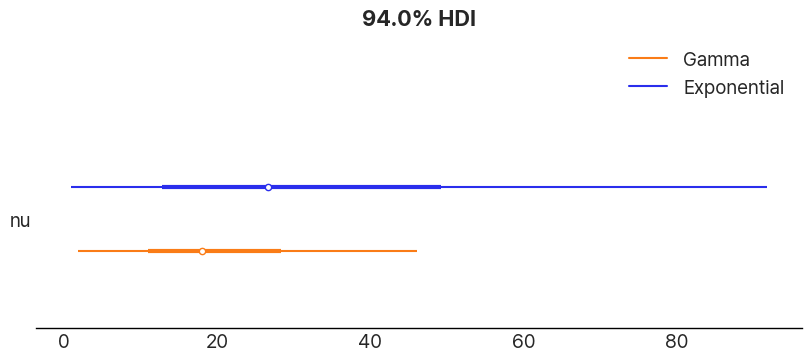

In [40]:
az.plot_forest([idata_t2_exp, idata_t2_gamma], model_names=["Exponential", "Gamma"], var_names=["nu"], figsize=(8, 3.5), combined=True);

array([[<Axes: >, <Axes: >, <Axes: xlabel='nu'>]], dtype=object)

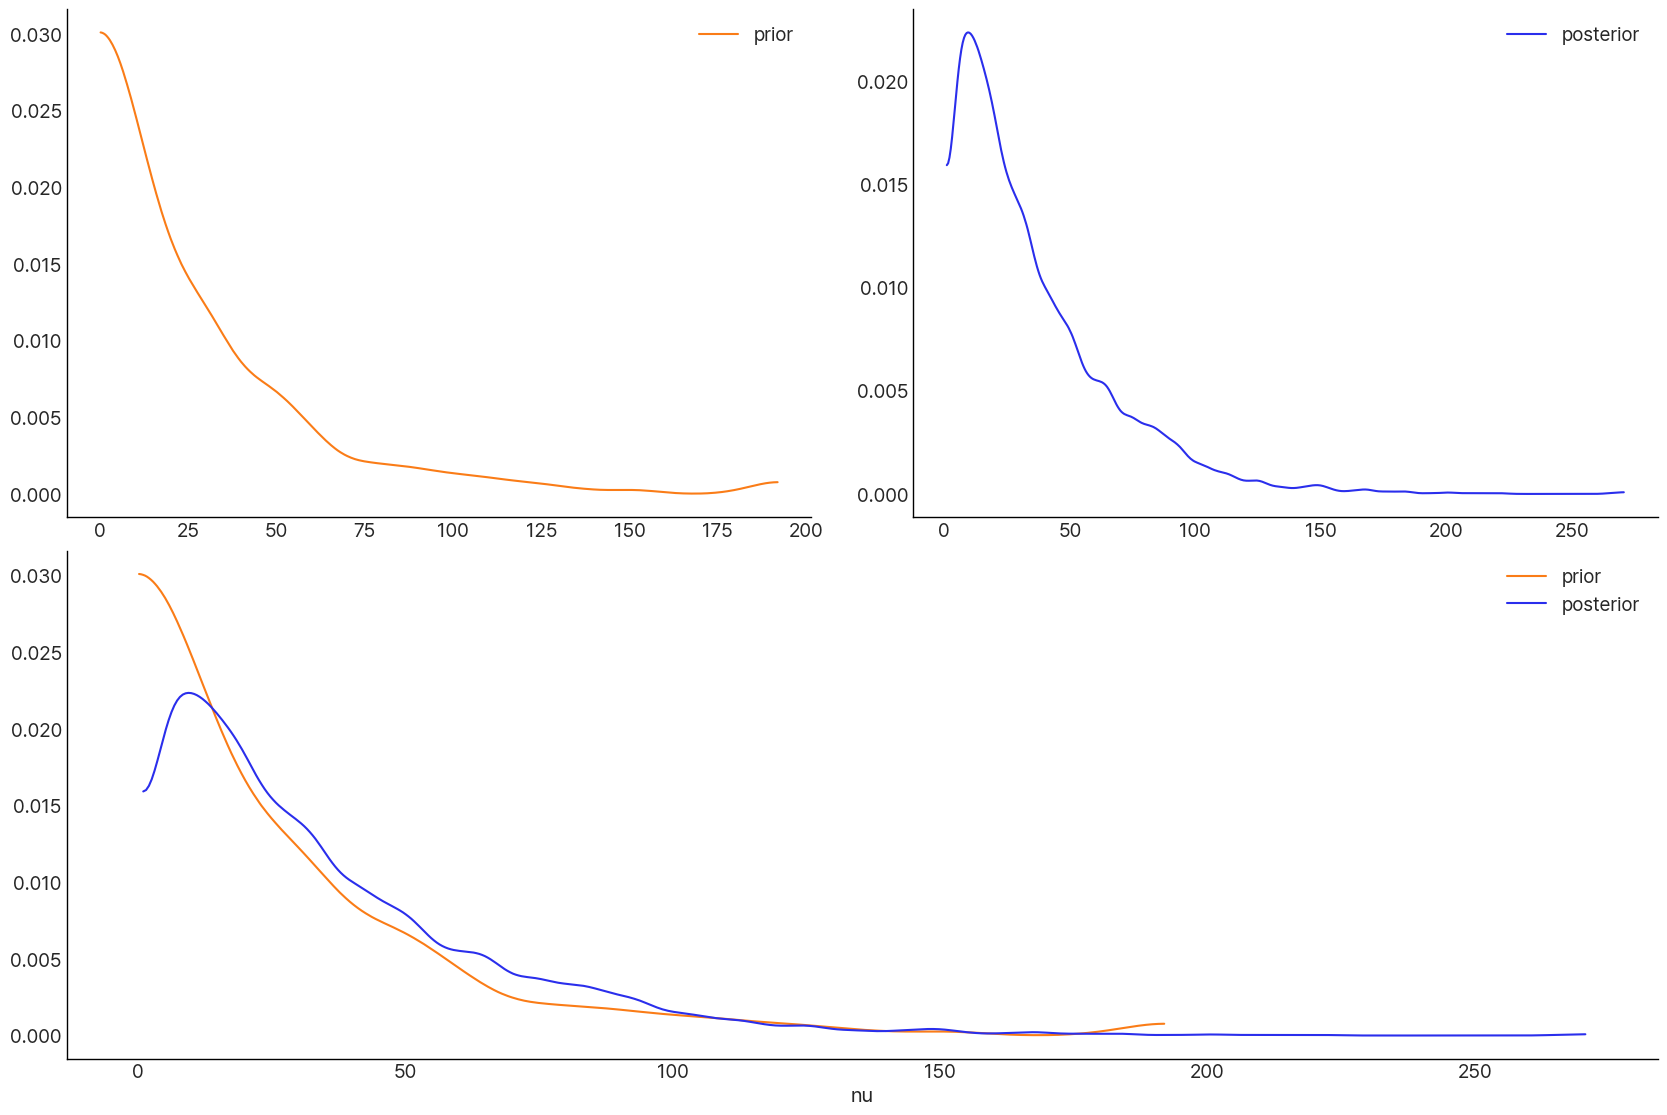

In [41]:
az.plot_dist_comparison(idata_t2_exp, var_names=['nu'])

array([[<Axes: >, <Axes: >, <Axes: xlabel='nu'>]], dtype=object)

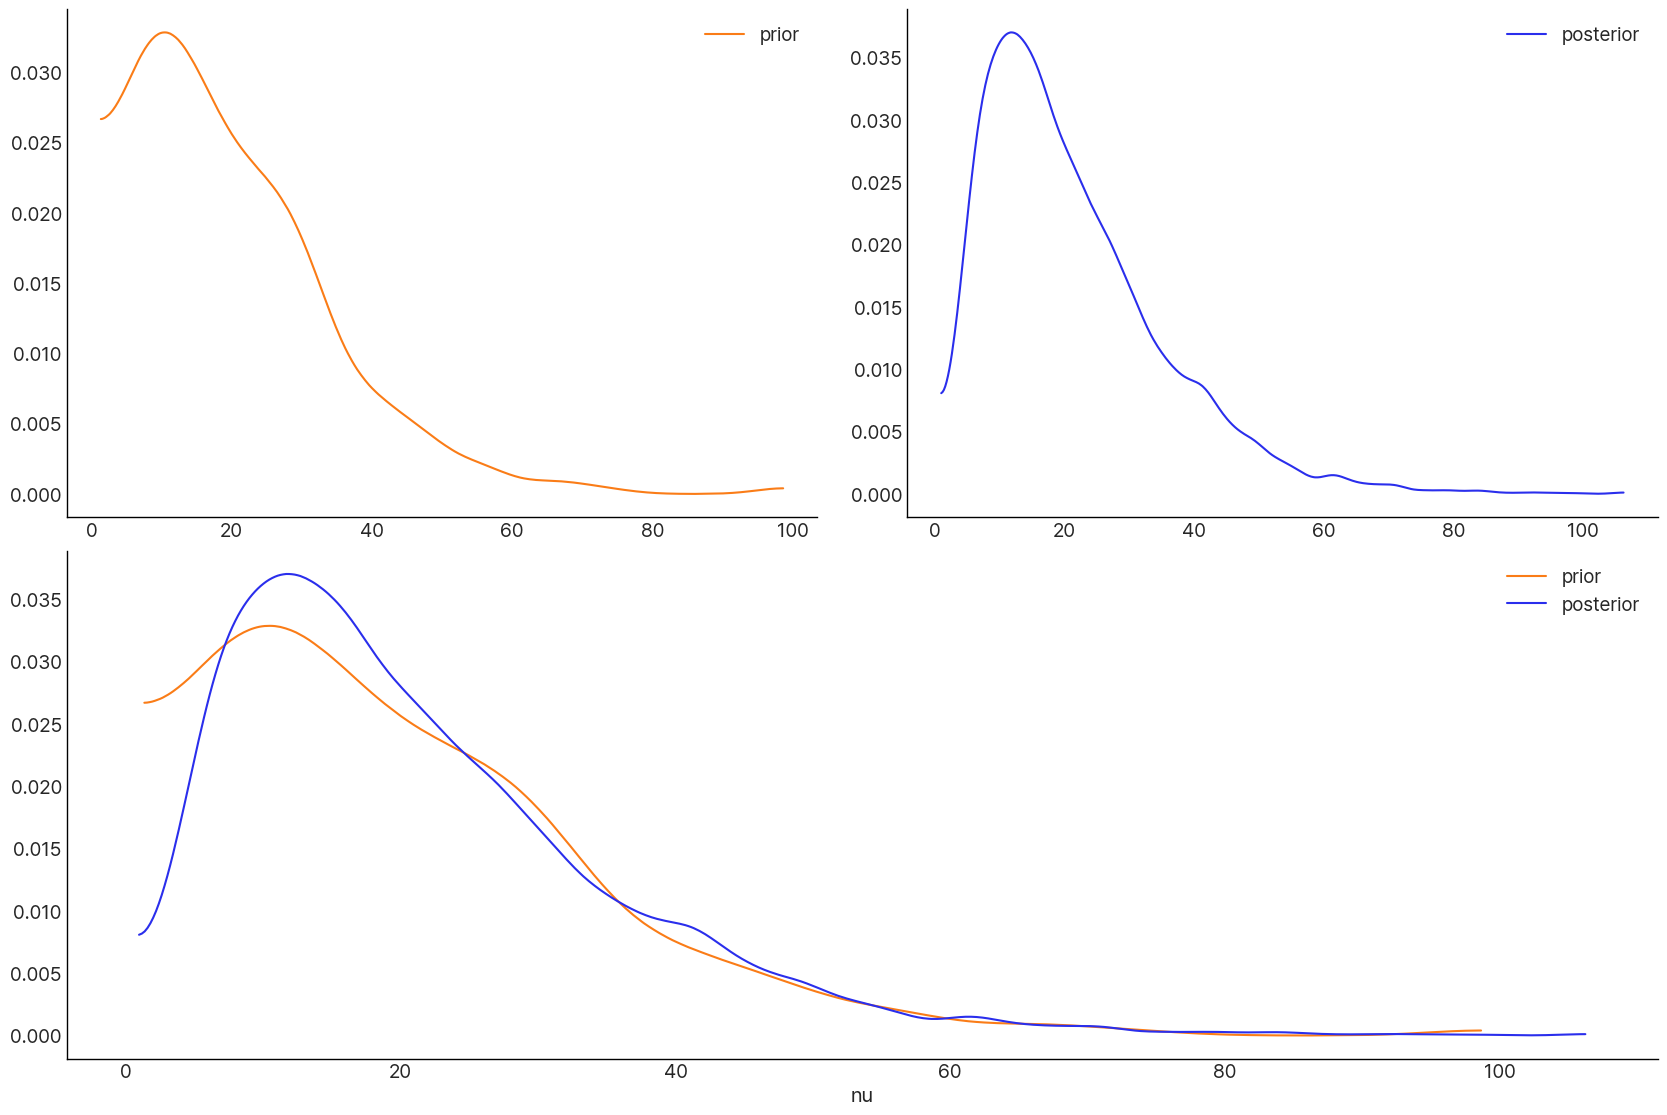

In [42]:
az.plot_dist_comparison(idata_t2_gamma, var_names=['nu'])

## Exercise 6

In [43]:
iris = pd.read_csv('../code/data/iris.csv')
df = iris.query("species == ('setosa', 'versicolor')")
y_0 = pd.Categorical(df['species']).codes

var_names = ['alpha', 'beta', 'bd']

In [45]:
for feature in ['sepal_length', 'petal_width', 'petal_length']:
    x_n = feature
    x_0 = df[x_n].values
    x_c = x_0 - x_0.mean()

    with pm.Model() as model_0:
        alpha = pm.Normal('alpha', mu=0, sigma=10)
        beta = pm.Normal('beta', mu=0, sigma=10)

        mu = alpha + pm.math.dot(x_c, beta)
        theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
        bd = pm.Deterministic('bd', -alpha/beta)

        yl = pm.Bernoulli('yl', p=theta, observed=y_0)

        idata_0 = pm.sample(target_accept=0.99)

        print(f"Feature {feature} summary")
        print(az.summary(idata_0, var_names=var_names))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...


Feature sepal_length summary
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.307  0.340  -0.324    0.910      0.008    0.006    1702.0    1785.0   
beta   5.386  1.030   3.640    7.445      0.024    0.018    1891.0    1977.0   
bd    -0.057  0.063  -0.174    0.061      0.001    0.001    1810.0    1828.0   

       r_hat  
alpha   1.00  
beta    1.00  
bd      1.01  


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 56 divergences after tuning. Increase `target_accept` or reparameterize.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...


Feature petal_width summary
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha   0.597  1.739  -2.670    4.082      0.058    0.042     927.0    1108.0   
beta   17.758  5.276   8.863   27.923      0.178    0.127     924.0    1413.0   
bd     -0.036  0.091  -0.207    0.126      0.003    0.002    1181.0    1818.0   

       r_hat  
alpha   1.00  
beta    1.01  
bd      1.00  


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.
There were 1192 divergences after tuning. Increase `target_accept` or reparameterize.


Feature petal_length summary
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha   2.442  2.816  -2.295    7.915      0.117    0.085     588.0     725.0   
beta   10.033  2.857   4.779   15.080      0.109    0.078     658.0     769.0   
bd     -0.258  0.279  -0.764    0.233      0.010    0.007     740.0    1167.0   

       r_hat  
alpha   1.01  
beta    1.00  
bd      1.00  


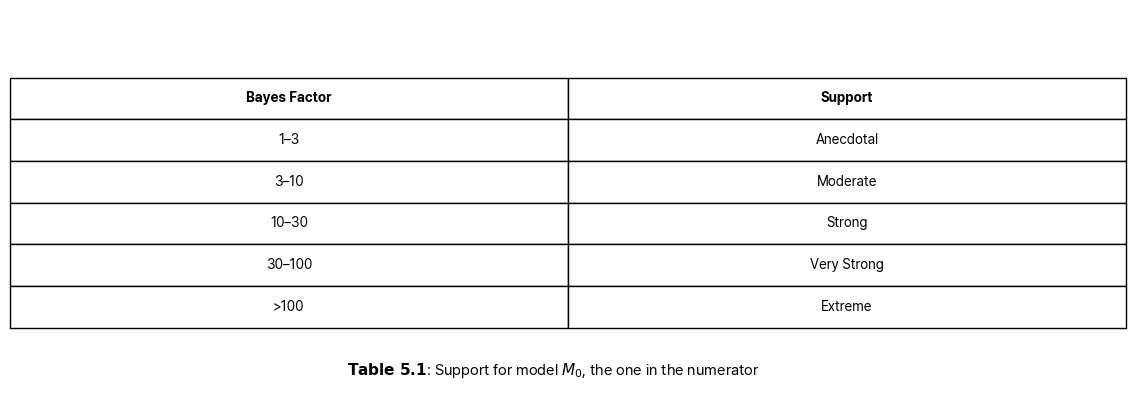

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 테이블 데이터 정의
data = {
    "Bayes Factor": ["1–3", "3–10", "10–30", "30–100", ">100"],
    "Support": ["Anecdotal", "Moderate", "Strong", "Very Strong", "Extreme"]
}
df = pd.DataFrame(data)

# Figure 생성
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

# 테이블 추가
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    colLoc='center',
    loc='center',
)

# 스타일 설정
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.5)

# 헤더 bold 처리
for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(weight='bold')

# 캡션 추가
fig.text(0.5, 0.15, r"$\mathbf{Table\ 5.1}$: Support for model $M_0$, the one in the numerator", ha='center', fontsize=11)

plt.show()